# tc_synthetic — Full Demonstration

`tc_synthetic` is a modular toolbox for generating synthetic multivariate data and analyzing the dependence it contains.
This walkthrough covers static generation, dynamic regime changes, special nonlinear structures, diagnostics, RBIG-based information metrics, and visualization.

## 1. Introduction

**Intuition.** The main idea of the toolbox is simple: define how data should look, generate it in a controlled way, and then measure whether the intended dependence pattern is actually present.

**Expected.** After the import cell, we will have access to the public API needed for generation, diagnostics, information metrics, and plots, together with a fixed random generator for reproducible results.

**Interpretation.** Each section that follows can be read as a reusable template: configure a process, generate a sample, and compare expectations with diagnostics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tc_synthetic import (
    StructureSpec,
    CopulaSpec,
    MarginalSpec,
    ScenarioSpec,
    StateProcessSpec,
    generate_static_scenario_data,
    generate_two_state_scenario_data,
    generate_special_structure_data,
    compute_basic_diagnostics,
    compute_correlation_diagnostics,
    compute_state_conditioned_diagnostics,
    compute_information_diagnostics,
    compute_state_conditioned_information_diagnostics,
    compute_pairwise_mutual_information,
    compute_pairwise_information_correlation,
    compute_state_conditioned_mutual_information,
    plot_sample_paths,
    plot_marginal_histograms,
    plot_correlation_heatmap,
    plot_state_path,
    plot_state_conditioned_histograms,
    plot_state_conditioned_correlation_heatmaps,
)

try:
    from tc_synthetic import compute_marginal_distribution_diagnostics
except ImportError:
    from tc_synthetic.diagnostics import compute_marginal_distribution_diagnostics

try:
    from tc_synthetic import (
        compute_gaussian_total_correlation,
        compute_excess_total_correlation,
    )
except ImportError:
    from tc_synthetic.information import (
        compute_gaussian_total_correlation,
        compute_excess_total_correlation,
    )

rng = np.random.default_rng(123)
RBIG_INSTALL_MESSAGE = "RBIG is not installed. Install it with: pip install 'git+https://github.com/ipl-uv/rbig.git'"

try:
    import rbig  # noqa: F401
    HAS_RBIG = True
except ImportError:
    HAS_RBIG = False

print("RBIG available:", HAS_RBIG)
print("Seed:", 123)

RBIG available: True
Seed: 123


c:\dev\asset-allocation-TC\.venv\Lib\site-packages\rbig\_src\training.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange


## 1A. Core Structures Overview

**Intuition.** The toolbox separates structure from copula and marginals so that dependence patterns can be studied independently from univariate distributional shape.

**Expected.** Different structures should induce clearly different correlation patterns: equicorrelation spreads dependence uniformly, block structures create clusters, near-duplicates generate very strong local redundancy, factor structures create common-driver behavior, and the independence copula removes dependence altogether.

**Interpretation.** Before looking at advanced diagnostics, it is useful to understand what each structural choice is supposed to encode. Diagnostics become much easier to interpret once the structural target is clear.

In [2]:
def _mean_offdiag(matrix: np.ndarray) -> float:
    mask = ~np.eye(matrix.shape[0], dtype=bool)
    return float(np.mean(matrix[mask]))

overview_marginal = MarginalSpec(kind="gaussian")
overview_gaussian_copula = CopulaSpec(kind="gaussian")
overview_independence_copula = CopulaSpec(kind="independence")

overview_samples = {
    "equicorrelation": generate_static_scenario_data(
        n_obs=500,
        n_assets=4,
        structure=StructureSpec(kind="equicorrelation", params={"rho": 0.5}),
        copula=overview_gaussian_copula,
        marginal=overview_marginal,
        rng=np.random.default_rng(123),
    ),
    "block": generate_static_scenario_data(
        n_obs=500,
        n_assets=4,
        structure=StructureSpec(
            kind="block",
            params={"block_sizes": [2, 2], "rho_within": 0.7, "rho_between": 0.1},
        ),
        copula=overview_gaussian_copula,
        marginal=overview_marginal,
        rng=np.random.default_rng(124),
    ),
    "near_duplicates": generate_static_scenario_data(
        n_obs=500,
        n_assets=4,
        structure=StructureSpec(
            kind="near_duplicates",
            params={"group_sizes": [2, 2], "rho_duplicate": 0.95, "rho_background": 0.1},
        ),
        copula=overview_gaussian_copula,
        marginal=overview_marginal,
        rng=np.random.default_rng(125),
    ),
    "factor": generate_static_scenario_data(
        n_obs=500,
        n_assets=4,
        structure=StructureSpec(
            kind="factor",
            params={"loadings": np.array([[0.85], [0.85], [0.25], [0.25]])},
        ),
        copula=overview_gaussian_copula,
        marginal=overview_marginal,
        rng=np.random.default_rng(126),
    ),
    "independence": generate_static_scenario_data(
        n_obs=500,
        n_assets=4,
        structure=StructureSpec(kind="equicorrelation", params={"rho": 0.5}),
        copula=overview_independence_copula,
        marginal=overview_marginal,
        rng=np.random.default_rng(127),
    ),
}

overview_summary = {}
for name, sample in overview_samples.items():
    corr = compute_correlation_diagnostics(sample)["correlation"]
    overview_summary[f"{name}_mean_offdiag"] = round(_mean_offdiag(corr), 3)

print(overview_summary)


{'equicorrelation_mean_offdiag': 0.508, 'block_mean_offdiag': 0.282, 'near_duplicates_mean_offdiag': 0.395, 'factor_mean_offdiag': 0.254, 'independence_mean_offdiag': -0.004}


## 2. Static Data Generation

**Intuition.** Static generation separates three layers: structure controls the target dependence pattern, the copula couples the variables, and the marginal fixes the shape of each univariate distribution.

**Expected.** We should obtain a sample with controlled dependence and clearly defined marginals.

**Interpretation.** If the configuration is working as intended, the generated data should reflect the chosen structure rather than an accidental pattern from random sampling.

In [3]:
static_structure = StructureSpec(
    kind="block",
    params={"block_sizes": [2, 2], "rho_within": 0.6, "rho_between": 0.1},
)
static_copula = CopulaSpec(kind="gaussian")
static_marginal = MarginalSpec(kind="student_t", params={"df": 5.0})

x_static = generate_static_scenario_data(
    n_obs=1000,
    n_assets=4,
    structure=static_structure,
    copula=static_copula,
    marginal=static_marginal,
    rng=rng,
)

print("Static sample shape:", x_static.shape)
print("First 3 rows:")
x_static[:3]

Static sample shape: (1000, 4)
First 3 rows:


array([[ 0.29445583,  0.44038939,  0.24965121,  1.3363079 ],
       [-0.4281072 , -0.02729033, -0.56254212, -1.10305911],
       [ 0.58889445, -0.55088041,  0.29484061,  0.36748946]])

## 3. Dynamic Regimes

**Intuition.** Many systems do not remain in a single regime. Here we model a calm state and a crisis state, with a Markov process controlling when the generator switches between them.

**Expected.** The crisis regime should typically show stronger dependence and heavier tails than the calm regime.

**Interpretation.** The easiest way to validate this behavior is to compare diagnostics on the full sample with diagnostics computed separately by state.

In [4]:
calm_spec = ScenarioSpec(
    name="calm",
    n_obs=1000,
    n_assets=4,
    structure=StructureSpec(kind="equicorrelation", params={"rho": 0.2}),
    copula=CopulaSpec(kind="gaussian"),
    marginal=MarginalSpec(kind="gaussian"),
)

crisis_spec = ScenarioSpec(
    name="crisis",
    n_obs=1000,
    n_assets=4,
    structure=StructureSpec(kind="equicorrelation", params={"rho": 0.7}),
    copula=CopulaSpec(kind="gaussian"),
    marginal=MarginalSpec(kind="student_t", params={"df": 5.0}),
)

state_spec = StateProcessSpec(
    kind="markov",
    params={
        "transition_matrix": np.array([[0.97, 0.03], [0.05, 0.95]], dtype=float),
        "initial_state": 0,
    },
    enabled=True,
)

x_dynamic, states = generate_two_state_scenario_data(
    calm_spec,
    crisis_spec,
    state_spec,
    rng,
)

print("Dynamic sample shape:", x_dynamic.shape)
print("State path shape:", states.shape)
print("State counts:", dict(zip(*np.unique(states, return_counts=True))))

Dynamic sample shape: (1000, 4)
State path shape: (1000,)
State counts: {np.int64(0): np.int64(698), np.int64(1): np.int64(302)}


## 4. Special Generators

**Intuition.** Linear correlation is not always enough. Some variables may carry redundant information through nonlinear relationships that ordinary covariance-based summaries do not capture well.

**Expected.** In a nonlinear redundancy example, pairwise correlation can remain modest while dependence is still clearly present.

**Interpretation.** This matters for asset or feature selection because variables that look different under correlation may still be informationally redundant.

In [5]:
special_structure = StructureSpec(
    kind="nonlinear_redundancy",
    params={"group_sizes": [2, 2]},
)
special_marginal = MarginalSpec(kind="gaussian")

x_special = generate_special_structure_data(
    n_obs=1000,
    n_assets=4,
    structure=special_structure,
    marginal=special_marginal,
    rng=np.random.default_rng(123),
)

print("Special sample shape:", x_special.shape)
print("First 3 rows:")
x_special[:3]

Special sample shape: (1000, 4)
First 3 rows:


array([[-1.00064183,  0.41929575,  0.19294761, -0.65417355],
       [-0.50294918, -0.37051339, -0.554846  , -0.08407098],
       [ 1.29014592,  0.84699125,  0.46350839, -0.52583911]])

## 5. Basic Diagnostics

**Intuition.** Basic diagnostics are first-pass sanity checks. Before studying dependence in detail, it helps to confirm that the sample has the expected shape, finite values, and reasonable first-order statistics.

**Expected.** For standardized generators, means should often be near zero and standard deviations should remain in a plausible range.

**Interpretation.** Large deviations here often indicate either a configuration issue or that a more detailed diagnostic is needed before trusting downstream analysis.

In [6]:
basic_static = compute_basic_diagnostics(x_static)

print("Basic diagnostics:")
print(basic_static)
print("Shape:", basic_static["shape"])
print("First two column means:", basic_static["column_means"][:2])
print("First two column stds:", basic_static["column_stds"][:2])

Basic diagnostics:
{'shape': (1000, 4), 'is_finite': True, 'column_means': array([-0.05113966, -0.01305265,  0.01442245,  0.0562199 ]), 'column_stds': array([0.99381317, 1.00186403, 1.01498296, 1.01041204]), 'column_mins': array([-5.524797  , -5.30489901, -5.60187828, -6.46049695]), 'column_maxs': array([3.27757408, 4.074438  , 4.84823359, 5.65867886])}
Shape: (1000, 4)
First two column means: [-0.05113966 -0.01305265]
First two column stds: [0.99381317 1.00186403]


## 6. Marginal Diagnostics

**Intuition.** Marginal diagnostics focus on the shape of each variable independently: asymmetry, tail weight, percentiles, and simple tail event ratios.

**Expected.** Gaussian marginals should have kurtosis near 3, while Student-t marginals should show heavier tails and larger kurtosis.

**Interpretation.** This is the main place to verify that the chosen marginals survive the full generation pipeline rather than being distorted by dependence modeling.

In [7]:
marginal_static = compute_marginal_distribution_diagnostics(x_static)
marginal_summary = {
    key: marginal_static[key]
    for key in ["mean", "std", "skew", "kurtosis", "tail_3sigma"]
}

print("Marginal diagnostics summary:")
print(marginal_summary)

Marginal diagnostics summary:
{'mean': array([-0.05113966, -0.01305265,  0.01442245,  0.0562199 ]), 'std': array([0.99381317, 1.00186403, 1.01498296, 1.01041204]), 'skew': array([-0.48977105, -0.10143969, -0.04569418,  0.17756821]), 'kurtosis': array([5.2873918 , 5.39334324, 6.53823273, 6.01986793]), 'tail_3sigma': array([0.01 , 0.014, 0.012, 0.011])}


## 7. Correlation Diagnostics

**Intuition.** Correlation diagnostics summarize linear dependence. They are fast, interpretable, and often the first tool used to confirm whether a structural pattern was successfully encoded.

**Expected.** A block structure should produce visible correlation clusters, while equicorrelation should look more uniform across off-diagonal entries.

**Interpretation.** Correlation is informative but limited: it can miss nonlinear relationships, so it should be treated as a partial view rather than a complete description.

In [8]:
corr_static = compute_correlation_diagnostics(x_static)

print("Linear correlation matrix:")
print(corr_static["correlation"])

if HAS_RBIG:
    rho_info_static = compute_pairwise_information_correlation(x_static, max_layers=30)
    print("Information-based equivalent correlation matrix:")
    print(rho_info_static)
else:
    print(RBIG_INSTALL_MESSAGE)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Linear correlation matrix:
[[1.         0.59879469 0.09829228 0.07381894]
 [0.59879469 1.         0.09316218 0.09522206]
 [0.09829228 0.09316218 1.         0.59506985]
 [0.07381894 0.09522206 0.59506985 1.        ]]


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Information-based equivalent correlation matrix:
[[0.         0.59929914 0.51511624 0.19393258]
 [0.59929914 0.         0.07089397 0.20223737]
 [0.51511624 0.07089397 0.         0.6369277 ]
 [0.19393258 0.20223737 0.6369277  0.        ]]


## 7A. Correlation vs Information Metrics

**Intuition.** Correlation only captures linear co-movement. Information-based metrics such as mutual information and total correlation can detect richer forms of dependence, including nonlinear redundancy.

**Expected.** A Gaussian linear example may already look dependent under correlation, while a nonlinear redundancy example may require information-based metrics to reveal how much structure is still shared.

**Interpretation.** This difference matters for asset-selection research because two assets can look only moderately correlated and still be informationally redundant.

In [9]:
def _mean_offdiag(matrix: np.ndarray) -> float:
    mask = ~np.eye(matrix.shape[0], dtype=bool)
    return float(np.mean(matrix[mask]))

x_linear_gaussian = generate_static_scenario_data(
    n_obs=1000,
    n_assets=4,
    structure=StructureSpec(kind="equicorrelation", params={"rho": 0.6}),
    copula=CopulaSpec(kind="gaussian"),
    marginal=MarginalSpec(kind="gaussian"),
    rng=np.random.default_rng(123),
)

comparison = {}
for name, sample in {
    "gaussian_linear": x_linear_gaussian,
    "nonlinear_redundancy": x_special,
}.items():
    corr = compute_correlation_diagnostics(sample)["correlation"]
    summary = {"linear_mean_offdiag": round(_mean_offdiag(corr), 3)}
    if HAS_RBIG:
        rho_info = compute_pairwise_information_correlation(sample, max_layers=30)
        info = compute_information_diagnostics(sample, max_layers=30)
        summary["information_mean_offdiag"] = round(_mean_offdiag(rho_info), 3)
        summary["total_correlation"] = round(float(info["total_correlation"]), 3)
    comparison[name] = summary

print(comparison)
if not HAS_RBIG:
    print(RBIG_INSTALL_MESSAGE)


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

{'gaussian_linear': {'linear_mean_offdiag': 0.598, 'information_mean_offdiag': 0.604, 'total_correlation': 0.83}, 'nonlinear_redundancy': {'linear_mean_offdiag': 0.008, 'information_mean_offdiag': 0.469, 'total_correlation': 0.791}}


## 8. Information Metrics (RBIG)

**Intuition.** RBIG-based information metrics go beyond linear summaries. Total correlation measures multivariate dependence, mutual information measures shared information between variables or blocks, and joint entropy summarizes the overall uncertainty of the sample.

**Expected.** Total correlation should be strictly positive when variables are dependent, and mutual information can reveal relationships that correlation underestimates.

**Interpretation.** These metrics are especially useful when hidden nonlinear dependence matters more than covariance structure alone.

In [10]:
if HAS_RBIG:
    info_static = compute_information_diagnostics(x_static, max_layers=30)
    mi_static = compute_pairwise_mutual_information(x_static, max_layers=30)
    print("Information diagnostics:")
    print(info_static)
    print("Pairwise mutual information matrix:")
    print(mi_static)
else:
    print(RBIG_INSTALL_MESSAGE)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Information diagnostics:
{'shape': (1000, 4), 'total_correlation': 0.39794363645425257, 'joint_entropy': 5.108486888515801, 'units': 'nats'}
Pairwise mutual information matrix:
[[0.         0.22248731 0.15417696 0.01916767]
 [0.22248731 0.         0.00251931 0.02087994]
 [0.15417696 0.00251931 0.         0.26016608]
 [0.01916767 0.02087994 0.26016608 0.        ]]


## 8A. Structural vs Functional Dependence

**Intuition.** Structural dependence refers to redundancy across the variables themselves. Functional dependence is about what happens after transforming or aggregating them into another output.

**Expected.** In this toolbox the first target is structural dependence: how much shared information is already present across the chosen variables before any downstream model is applied.

**Interpretation.** Total correlation is useful here because it acts as a structural redundancy measure, not just a summary of pairwise linear association.

In [11]:
def _mean_offdiag(matrix: np.ndarray) -> float:
    mask = ~np.eye(matrix.shape[0], dtype=bool)
    return float(np.mean(matrix[mask]))

x_block_gaussian = generate_static_scenario_data(
    n_obs=1000,
    n_assets=4,
    structure=static_structure,
    copula=static_copula,
    marginal=MarginalSpec(kind="gaussian"),
    rng=np.random.default_rng(321),
)

structural_summary = {}
for name, sample in {
    "block_based": x_block_gaussian,
    "nonlinear_redundancy": x_special,
}.items():
    corr = compute_correlation_diagnostics(sample)["correlation"]
    summary = {"linear_mean_offdiag": round(_mean_offdiag(corr), 3)}
    if HAS_RBIG:
        mi = compute_pairwise_mutual_information(sample, max_layers=30)
        info = compute_information_diagnostics(sample, max_layers=30)
        summary["mean_offdiag_mi"] = round(_mean_offdiag(mi), 3)
        summary["total_correlation"] = round(float(info["total_correlation"]), 3)
    structural_summary[name] = summary

print(structural_summary)
if not HAS_RBIG:
    print(RBIG_INSTALL_MESSAGE)


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

{'block_based': {'linear_mean_offdiag': 0.277, 'mean_offdiag_mi': 0.117, 'total_correlation': 0.471}, 'nonlinear_redundancy': {'linear_mean_offdiag': 0.008, 'mean_offdiag_mi': 0.267, 'total_correlation': 0.791}}


## 9. Gaussian Benchmark and Excess Dependence

**Intuition.** A useful decomposition is `TC = TC_G + Xi`, where `TC_G` is the Gaussian benchmark implied by rank-gaussianized correlation and `Xi` captures the excess dependence beyond that benchmark.

**Expected.** For data that is close to Gaussian, `Xi` should be near zero. For nonlinear or non-Gaussian structures, `Xi` should become positive.

**Interpretation.** This gives a practical way to separate dependence that is explainable by Gaussian correlation from dependence that is structurally non-Gaussian.

In [12]:
tc_gauss_static = compute_gaussian_total_correlation(x_static)
print("Gaussian benchmark total correlation:", tc_gauss_static)

if HAS_RBIG:
    xi_static = compute_excess_total_correlation(x_static, max_layers=30)
    print("Excess total correlation relative to Gaussian benchmark:", xi_static)
else:
    print(RBIG_INSTALL_MESSAGE)

Gaussian benchmark total correlation: 0.45934729927783563
Excess total correlation relative to Gaussian benchmark: -0.06140366282358306


## 9A. Interpreting Excess Dependence (Xi)

**Intuition.** Gaussian total correlation is the benchmark implied by the Gaussianized correlation matrix. Excess dependence `Xi` measures what remains after that benchmark has been removed.

**Expected.** In approximately Gaussian dependence, `Xi` should stay close to zero. In strongly non-Gaussian settings, `Xi` should become positive.

**Interpretation.** This makes `Xi` a practical measure of structural non-Gaussianity rather than just overall dependence strength.

In [13]:
xi_comparison = {
    "gaussian_linear": {
        "gaussian_benchmark_tc": round(compute_gaussian_total_correlation(x_linear_gaussian), 3),
    },
    "nonlinear_redundancy": {
        "gaussian_benchmark_tc": round(compute_gaussian_total_correlation(x_special), 3),
    },
}

if HAS_RBIG:
    xi_comparison["gaussian_linear"]["total_correlation"] = round(
        float(compute_information_diagnostics(x_linear_gaussian, max_layers=30)["total_correlation"]),
        3,
    )
    xi_comparison["gaussian_linear"]["excess_xi"] = round(
        compute_excess_total_correlation(x_linear_gaussian, max_layers=30),
        3,
    )
    xi_comparison["nonlinear_redundancy"]["total_correlation"] = round(
        float(compute_information_diagnostics(x_special, max_layers=30)["total_correlation"]),
        3,
    )
    xi_comparison["nonlinear_redundancy"]["excess_xi"] = round(
        compute_excess_total_correlation(x_special, max_layers=30),
        3,
    )

print(xi_comparison)
if not HAS_RBIG:
    print(RBIG_INSTALL_MESSAGE)


{'gaussian_linear': {'gaussian_benchmark_tc': 0.85, 'total_correlation': 0.83, 'excess_xi': -0.02}, 'nonlinear_redundancy': {'gaussian_benchmark_tc': 0.001, 'total_correlation': 0.791, 'excess_xi': 0.79}}


## 10. State-Conditioned Analysis

**Intuition.** When a sample mixes regimes, aggregate diagnostics can hide the real behavior. Conditioning on the state path lets us inspect each regime separately.

**Expected.** The crisis state should often display stronger dependence and heavier tails, while the calm state should remain closer to the low-stress configuration.

**Interpretation.** This is the clearest way to validate that dynamic routing is working and that regime-specific parameters are actually reflected in the generated data.

In [14]:
state_diag = compute_state_conditioned_diagnostics(x_dynamic, states)

print("State-conditioned basic/correlation diagnostics:")
print(state_diag)

if HAS_RBIG:
    state_info = compute_state_conditioned_information_diagnostics(
        x_dynamic,
        states,
        max_layers=30,
    )
    state_mi = compute_state_conditioned_mutual_information(
        x_dynamic,
        states,
        max_layers=30,
    )
    print("State-conditioned information diagnostics:")
    print(state_info)
    print("Mutual-information matrix shapes by state:")
    print({key: value.shape for key, value in state_mi.items()})
else:
    print(RBIG_INSTALL_MESSAGE)

State-conditioned basic/correlation diagnostics:
{'state_0': {'n_obs': 698, 'shape': (698, 4), 'is_finite': True, 'column_means': array([ 0.05254049, -0.0274993 ,  0.00474556,  0.00256002]), 'column_stds': array([1.00844565, 0.99899365, 1.02353101, 1.00256276]), 'correlation': array([[1.        , 0.24151393, 0.2262812 , 0.20846614],
       [0.24151393, 1.        , 0.21158013, 0.23197774],
       [0.2262812 , 0.21158013, 1.        , 0.19423403],
       [0.20846614, 0.23197774, 0.19423403, 1.        ]])}, 'state_1': {'n_obs': 302, 'shape': (302, 4), 'is_finite': True, 'column_means': array([ 0.03886323, -0.0004404 ,  0.07212634,  0.04380489]), 'column_stds': array([0.99206616, 0.94775465, 0.95598527, 0.92967481]), 'correlation': array([[1.        , 0.71092132, 0.73357176, 0.66101394],
       [0.71092132, 1.        , 0.75840577, 0.7167728 ],
       [0.73357176, 0.75840577, 1.        , 0.7244337 ],
       [0.66101394, 0.7167728 , 0.7244337 , 1.        ]])}}


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

State-conditioned information diagnostics:
{'state_0': {'shape': (698, 4), 'total_correlation': 0.12145185115448331, 'joint_entropy': 5.581189138826742, 'units': 'nats'}, 'state_1': {'shape': (302, 4), 'total_correlation': 1.3201653034224847, 'joint_entropy': 4.049159572422706, 'units': 'nats'}}
Mutual-information matrix shapes by state:
{'state_0': (4, 4), 'state_1': (4, 4)}


## 10A. Incremental Dependence (Selection Intuition)

**Intuition.** In asset selection, one often starts from a candidate variable and asks how redundant the remaining variables are relative to it. Pairwise mutual information provides a useful first approximation of that incremental redundancy.

**Expected.** Variables that are strongly linked to the reference variable should have larger mutual information values, even if plain correlation is not the full story.

**Interpretation.** This is only a selection intuition, not yet a full selection algorithm, but it helps connect dependence diagnostics to research use cases.

In [15]:
if HAS_RBIG:
    try:
        from tc_synthetic import estimate_rbig_mutual_information
    except ImportError:
        from tc_synthetic.information import estimate_rbig_mutual_information

    reference_index = 0
    mi_ranking = []
    for j in range(1, x_static.shape[1]):
        mi_value = estimate_rbig_mutual_information(
            x_static[:, [reference_index]],
            x_static[:, [j]],
            max_layers=30,
        )
        mi_ranking.append((j, float(mi_value)))

    mi_ranking.sort(key=lambda item: item[1])
    print(f"Reference variable: column {reference_index}")
    print("Ranked pairwise mutual information (low to high):")
    for column_index, mi_value in mi_ranking:
        print(f"column {column_index}: {mi_value:.3f}")
else:
    print(RBIG_INSTALL_MESSAGE)


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Reference variable: column 0
Ranked pairwise mutual information (low to high):
column 3: 0.019
column 2: 0.154
column 1: 0.222


## 10B. Core Functions vs Diagnostics

**Core functions** are intended for direct use inside algorithms, scoring rules, and optimization routines. **Diagnostics** are intended for validation, interpretation, and exploratory analysis.

In this toolbox:
- Core functions: `estimate_rbig_total_correlation`, `estimate_rbig_mutual_information`, `compute_gaussian_total_correlation`, `compute_excess_total_correlation`
- Diagnostics: `compute_basic_diagnostics`, `compute_correlation_diagnostics`, `compute_information_diagnostics`, `compute_state_conditioned_information_diagnostics`

**Key idea.** Diagnostics return richer summaries, while core functions return direct metrics suitable for algorithmic use.


In [ ]:
basic_demo = compute_basic_diagnostics(x_static)

if HAS_RBIG:
    try:
        from tc_synthetic import estimate_rbig_total_correlation
    except ImportError:
        from tc_synthetic.information import estimate_rbig_total_correlation

    tc_core = estimate_rbig_total_correlation(x_static, max_layers=30)
    info_demo = compute_information_diagnostics(x_static, max_layers=30)
    print("Core metric example:")
    print(tc_core)
    print("Diagnostic summary example keys:")
    print(basic_demo.keys())
    print(info_demo.keys())
else:
    print("Diagnostic summary example keys:")
    print(basic_demo.keys())
    print(RBIG_INSTALL_MESSAGE)


## 11. Visualizations

**Intuition.** Plots complement numerical diagnostics by making temporal, marginal, and dependence patterns easier to inspect quickly.

**Expected.** Sample paths, histograms, heatmaps, and state-aware plots should make the structural patterns visually visible.

**Interpretation.** Visual output should support the metrics above rather than replace them: use plots to spot patterns and diagnostics to quantify them.

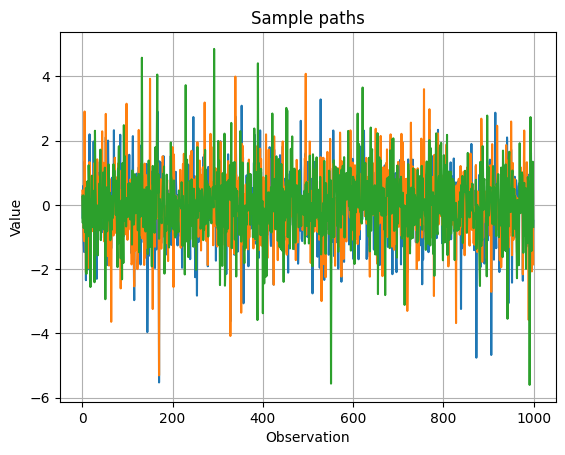

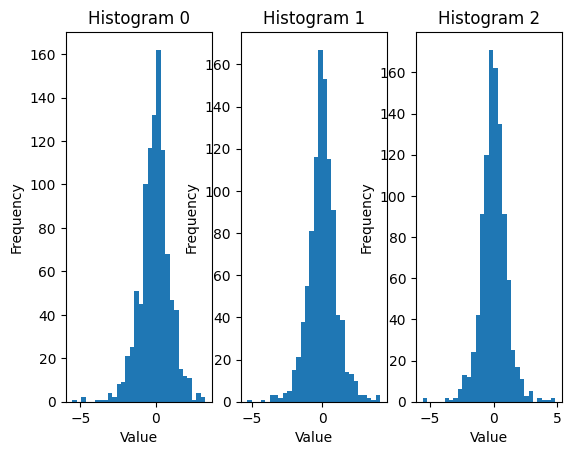

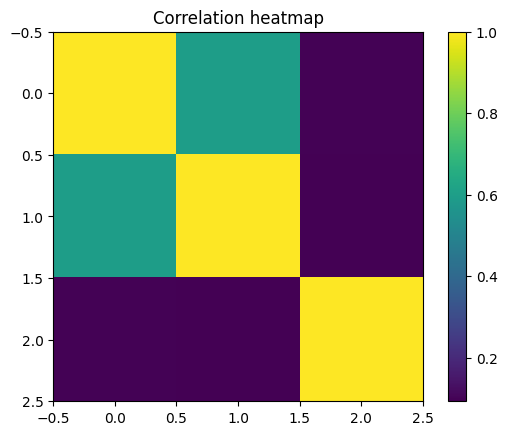

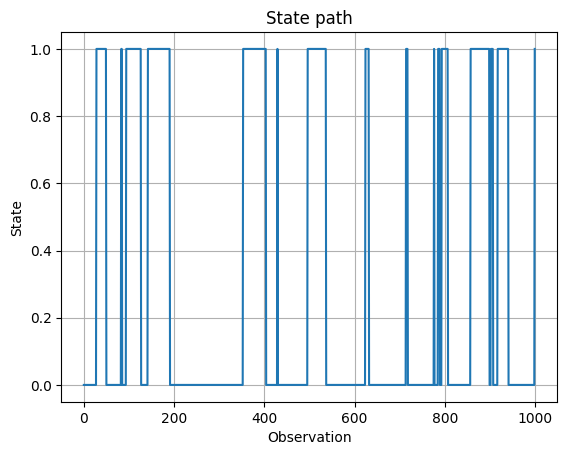

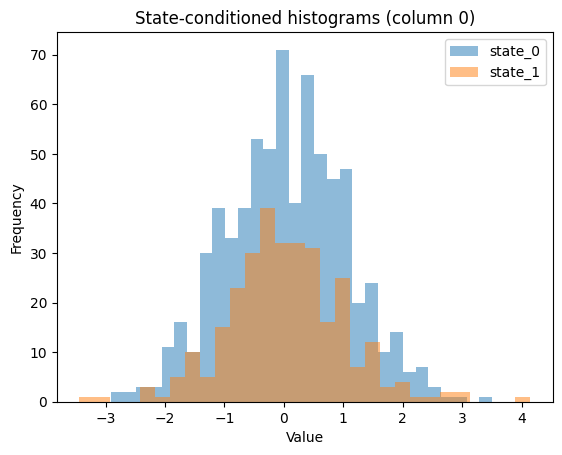

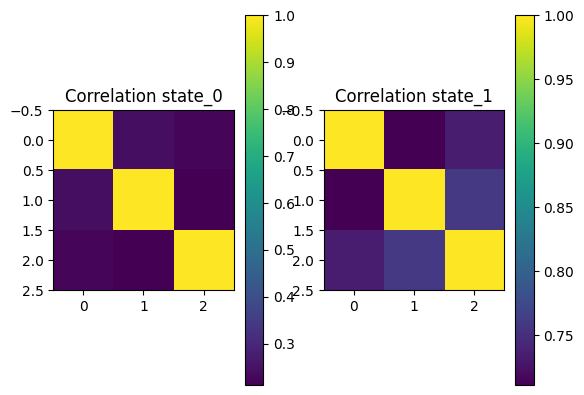

In [16]:
fig1, ax1 = plot_sample_paths(x_static[:, :3])
fig2, axes2 = plot_marginal_histograms(x_static[:, :3])
fig3, ax3 = plot_correlation_heatmap(x_static[:, :3])
fig4, ax4 = plot_state_path(states)
fig5, ax5 = plot_state_conditioned_histograms(x_dynamic[:, :3], states, column_index=0)
fig6, axes6 = plot_state_conditioned_correlation_heatmaps(x_dynamic[:, :3], states)

plt.show()

## 11A. Evolution of Total Correlation

**Intuition.** Total correlation can be tracked as variables are added sequentially. This gives a simple view of how redundancy accumulates as the candidate set grows.

**Expected.** In a dependent sample, the cumulative redundancy should generally increase as more variables are added.

**Interpretation.** This kind of progression is useful for future selection heuristics because it links subset size to incremental dependence burden.

In [17]:
if HAS_RBIG:
    subset_sizes = []
    tc_progression = []
    for subset_size in range(1, x_static.shape[1] + 1):
        subset_sizes.append(subset_size)
        if subset_size == 1:
            tc_progression.append(0.0)
        else:
            tc_value = compute_information_diagnostics(
                x_static[:, :subset_size],
                max_layers=30,
            )["total_correlation"]
            tc_progression.append(round(float(tc_value), 3))

    print({"subset_sizes": subset_sizes, "total_correlation": tc_progression})
else:
    print(RBIG_INSTALL_MESSAGE)


{'subset_sizes': [1, 2, 3, 4], 'total_correlation': [0.0, 0.173, 0.197, 0.398]}


## 11B. Smoke Utilities

Smoke utilities provide short end-to-end checks of the toolbox. They are useful for sanity checks, quick environment validation, and regression testing.

They are not meant to replace detailed experiments, but they are a compact demonstration of the full workflow.


In [ ]:
from tc_synthetic import run_static_smoke, run_dynamic_smoke, run_special_smoke

static_smoke = run_static_smoke()
dynamic_smoke = run_dynamic_smoke()
special_smoke = run_special_smoke()

print("Static smoke shape:", static_smoke["x"].shape)
print("Static smoke keys:", static_smoke.keys())
print("Dynamic smoke x shape:", dynamic_smoke["x"].shape)
print("Dynamic smoke states shape:", dynamic_smoke["states"].shape)
print("Dynamic smoke keys:", dynamic_smoke.keys())
print("Special smoke shape:", special_smoke["x"].shape)
print("Special smoke keys:", special_smoke.keys())


## 12. Key Takeaways

- Correlation is useful, but it is not sufficient to describe all forms of dependence.
- Mutual information and total correlation capture nonlinear structure that linear diagnostics can miss.
- The Gaussian benchmark and the excess term `Xi` help separate Gaussian-style dependence from genuinely non-Gaussian structure.
- The toolbox is designed for controlled experiments where generation, diagnostics, and interpretation stay tightly connected.